<a href="https://colab.research.google.com/github/yizhenhong9-alt/AIoT_DA_HW2/blob/main/Red_Wine_Quality_CRISPDM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Red Wine Quality Analysis — CRISP-DM

This notebook follows the **CRISP-DM** methodology to analyze and model the **Red Wine Quality** dataset (Kaggle / UCI). It includes EDA, preprocessing, modeling (regression & classification), evaluation, and model saving. Designed to run in a **Kaggle Notebook** environment.

## Step 1: Business Understanding

**Goal:** Predict wine quality from physicochemical measurements. Discuss business value: quality control, optimizing fermentation, identifying poor batches early.

**Deliverables:**
- Exploratory Data Analysis (EDA)
- Build & compare models (regression and classification)
- Evaluate and save the best model


In [21]:
# Step 2: Setup - imports and dataset discovery
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')

# Find the CSV file (works on Kaggle and local)
candidates = glob.glob('/content/winequality-red.csv', recursive=True) + glob.glob('**/winequality-red*.csv', recursive=True)
if len(candidates) == 0:
    candidates = glob.glob('/content/winequality-red.csv', recursive=True) + glob.glob('**/winequality*.csv', recursive=True)

print('Found files:', candidates[:5])
data_path = candidates[0] if candidates else 'winequality-red.csv'
print('Using:', data_path)


Found files: ['/content/winequality-red.csv', 'winequality-red.csv']
Using: /content/winequality-red.csv


In [22]:
# Load dataset
df = pd.read_csv(data_path, sep=',') # Changed delimiter to comma
print('Shape:', df.shape)
df.head()

Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [23]:
# Basic info
display(df.info())
display(df.describe().T)

# Missing values
print('\nMissing values per column:')
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


None

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000



Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


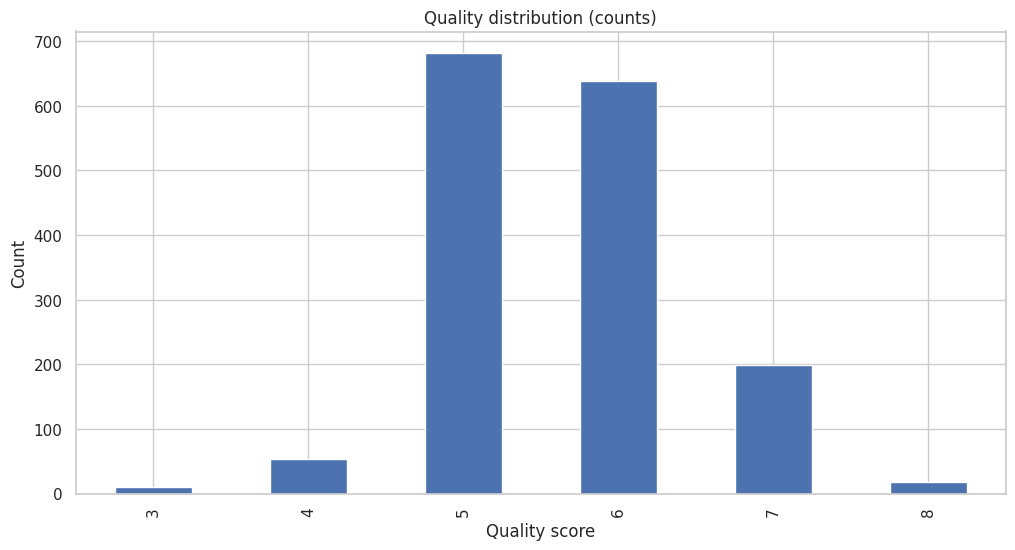

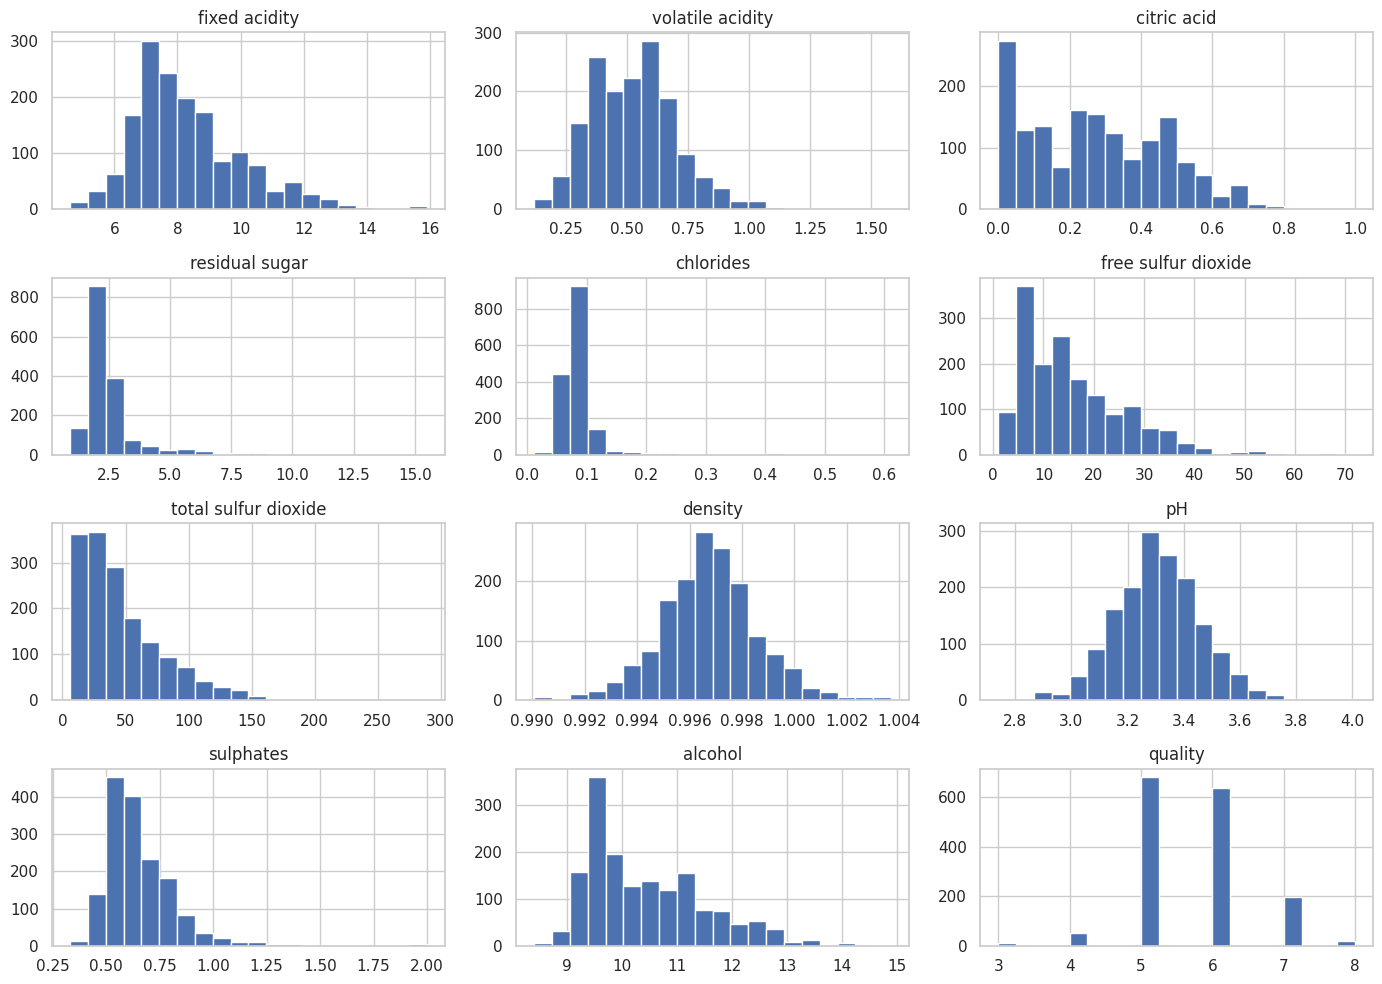

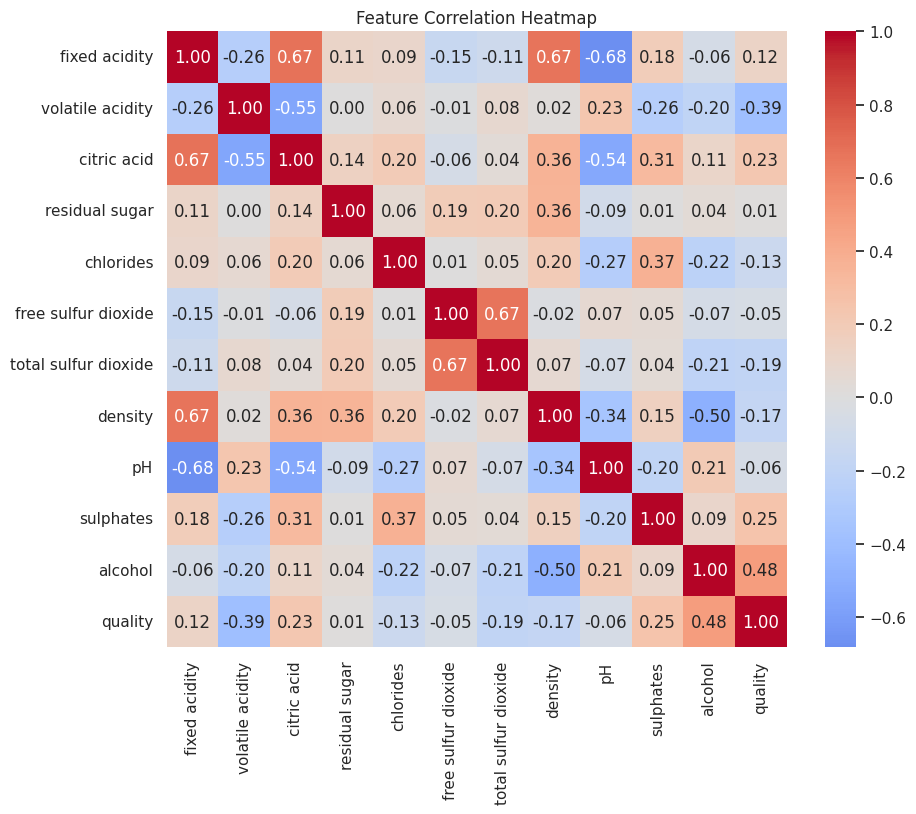

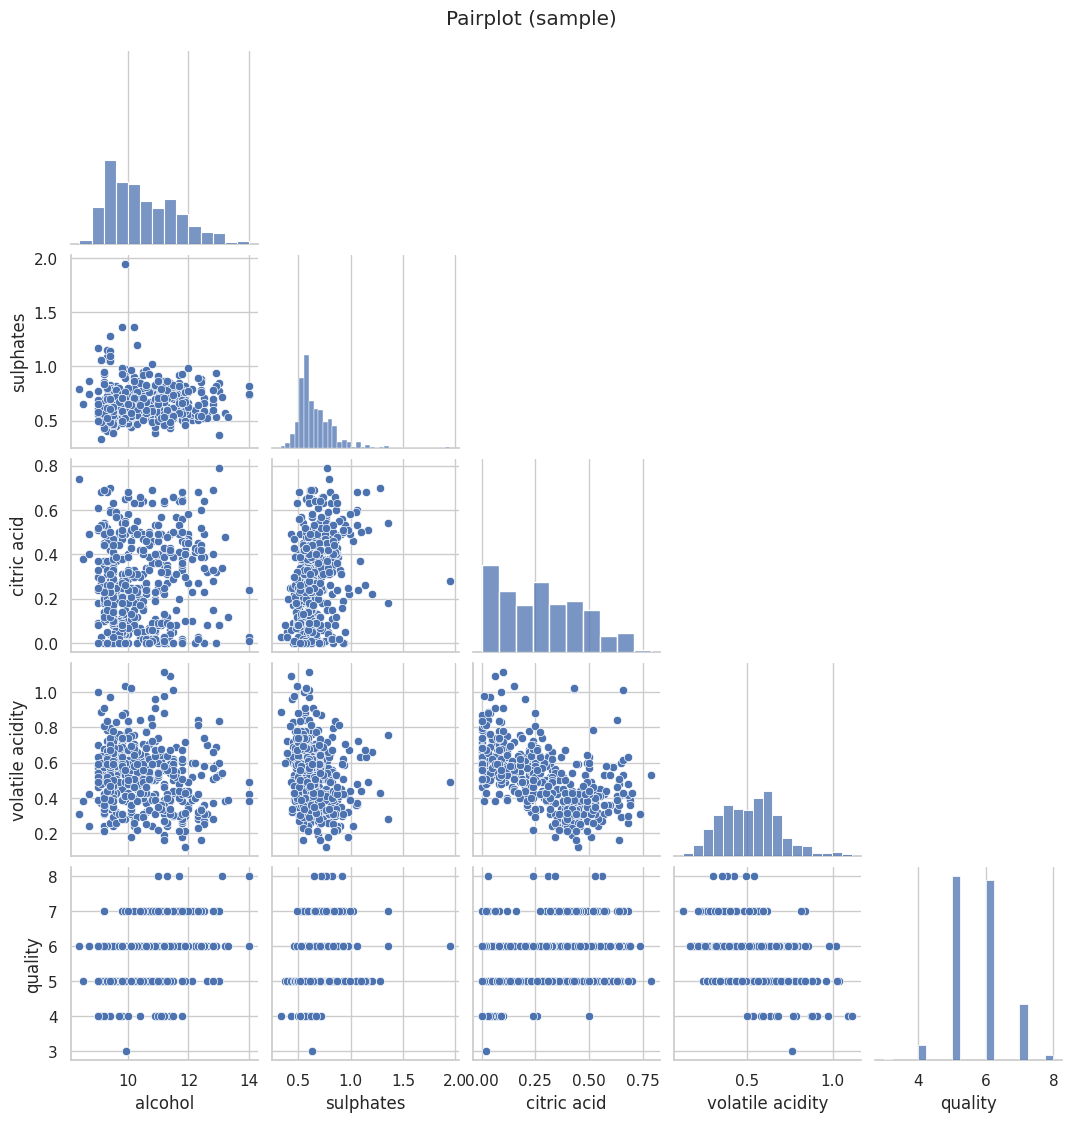

In [24]:
# Visualizations
plt.figure(figsize=(12,6))
df['quality'].value_counts().sort_index().plot(kind='bar')
plt.title('Quality distribution (counts)')
plt.xlabel('Quality score')
plt.ylabel('Count')
plt.show()

# Feature distributions (histograms)
df.hist(bins=20, figsize=(14,10))
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True) # Added numeric_only=True to calculate correlation only for numeric columns
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

# Pairplot sample (subsample to keep it fast)
sample = df.sample(500, random_state=42)
sns.pairplot(sample[['alcohol','sulphates','citric acid','volatile acidity','quality']], corner=True, height=2.2)
plt.suptitle('Pairplot (sample)', y=1.02)
plt.show()

In [25]:
# Step 3: Data Preparation
X = df.drop('quality', axis=1)
y_reg = df['quality'].copy()

def quality_to_label(q):
    if q <= 5:
        return 0  # low
    elif q == 6:
        return 1  # medium
    else:
        return 2  # high

y_clf = df['quality'].apply(quality_to_label)

print('Regression target stats:\n', y_reg.describe())
print('\nClassification label counts:\n', y_clf.value_counts())


Regression target stats:
 count    1599.000000
mean        5.636023
std         0.807569
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         8.000000
Name: quality, dtype: float64

Classification label counts:
 quality
0    744
1    638
2    217
Name: count, dtype: int64


In [26]:
# Train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

print('Regression train/test sizes:', X_train_reg.shape, X_test_reg.shape)
print('Classification train/test sizes:', X_train_clf.shape, X_test_clf.shape)


Regression train/test sizes: (1279, 11) (320, 11)
Classification train/test sizes: (1279, 11) (320, 11)


In [27]:
# Step 4: Modeling - Regression
regressors = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

regression_results = {}

for name, estimator in regressors.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', estimator)
    ])
    if name == 'LinearRegression':
        param_grid = {}
    elif name == 'RandomForest':
        param_grid = {'model__n_estimators': [100], 'model__max_depth': [8, 12]}
    else:
        param_grid = {'model__n_estimators': [100], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 5]}

    gs = GridSearchCV(pipe, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
    gs.fit(X_train_reg, y_train_reg)
    best = gs.best_estimator_
    preds = best.predict(X_test_reg)
    rmse = np.sqrt(mean_squared_error(y_test_reg, preds))
    mae = mean_absolute_error(y_test_reg, preds)
    r2 = r2_score(y_test_reg, preds)
    regression_results[name] = {'model': best, 'rmse': rmse, 'mae': mae, 'r2': r2, 'cv_best_params': gs.best_params_}
    print(f"{name}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}, params={gs.best_params_}")

LinearRegression: RMSE=0.6245, MAE=0.5035, R2=0.4032, params={}
RandomForest: RMSE=0.5546, MAE=0.4321, R2=0.5293, params={'model__max_depth': 12, 'model__n_estimators': 100}
GradientBoosting: RMSE=0.5892, MAE=0.4564, R2=0.4688, params={'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 100}


Best regression model: RandomForest


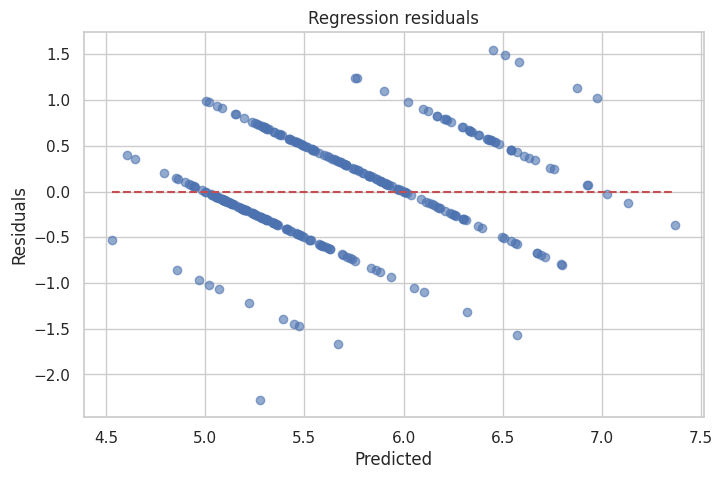

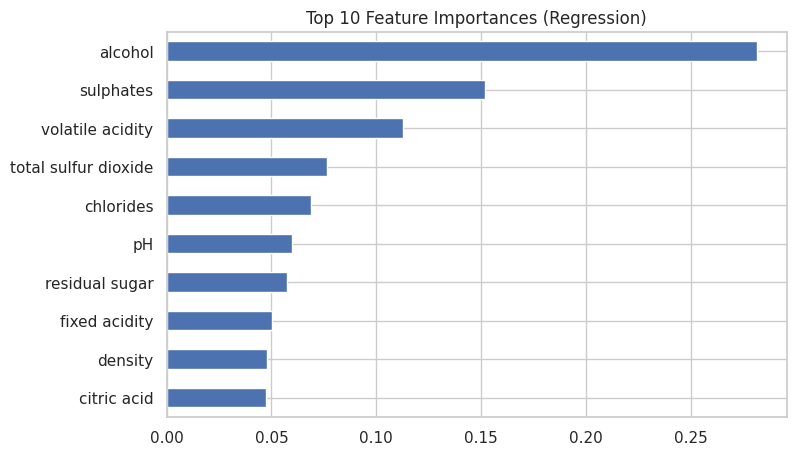

In [28]:
# Regression residuals (best model among tested)
best_reg_name = min(regression_results, key=lambda k: regression_results[k]['rmse'])
best_reg = regression_results[best_reg_name]['model']
print('Best regression model:', best_reg_name)

preds = best_reg.predict(X_test_reg)
residuals = y_test_reg - preds

plt.figure(figsize=(8,5))
plt.scatter(preds, residuals, alpha=0.6)
plt.hlines(0, xmin=preds.min(), xmax=preds.max(), colors='r', linestyles='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Regression residuals')
plt.show()

# Feature importance if available
if hasattr(best_reg.named_steps['model'], 'feature_importances_'):
    fi = best_reg.named_steps['model'].feature_importances_
    feat_imp = pd.Series(fi, index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(8,5))
    feat_imp.head(10).plot(kind='barh')
    plt.gca().invert_yaxis()
    plt.title('Top 10 Feature Importances (Regression)')
    plt.show()
else:
    print('No feature_importances_ attribute for model:', type(best_reg.named_steps['model']))


In [29]:
# Step 4: Modeling - Classification
classifiers = {
    'LogisticRegression': LogisticRegression(max_iter=200, multi_class='multinomial', solver='lbfgs'),
    'RandomForest': RandomForestClassifier(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

classification_results = {}

for name, estimator in classifiers.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', estimator)
    ])
    if name == 'LogisticRegression':
        param_grid = {'model__C': [0.1, 1.0, 5.0]}
    elif name == 'RandomForest':
        param_grid = {'model__n_estimators': [100], 'model__max_depth': [8, 12]}
    else:
        param_grid = {'model__n_estimators': [100], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3,5]}

    gs = GridSearchCV(pipe, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
    gs.fit(X_train_clf, y_train_clf)
    best = gs.best_estimator_
    preds = best.predict(X_test_clf)
    acc = accuracy_score(y_test_clf, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test_clf, preds, average='macro', zero_division=0)
    classification_results[name] = {'model': best, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'params': gs.best_params_}
    print(f"{name}: Acc={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}, params={gs.best_params_}")


LogisticRegression: Acc=0.6562, Precision=0.6605, Recall=0.5845, F1=0.6047, params={'model__C': 5.0}
RandomForest: Acc=0.7594, Precision=0.7740, Recall=0.7370, F1=0.7527, params={'model__max_depth': 12, 'model__n_estimators': 100}
GradientBoosting: Acc=0.7750, Precision=0.7418, Recall=0.7570, F1=0.7466, params={'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 100}


Top 10 Selected Features:
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'chlorides',
       'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH',
       'sulphates', 'alcohol'],
      dtype='object')


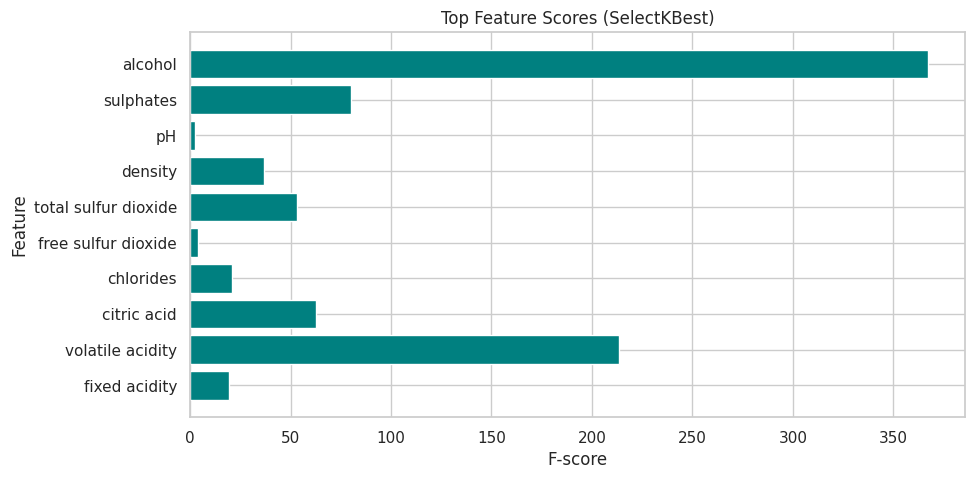

In [30]:
# ## Step 4.5: Feature Selection
from sklearn.feature_selection import SelectKBest, f_regression
import matplotlib.pyplot as plt
import numpy as np

# Select top K features
K = 10
selector = SelectKBest(score_func=f_regression, k=K)
X_new = selector.fit_transform(X_train_reg, y_train_reg) # Use regression training data

selected_features = X_train_reg.columns[selector.get_support()] # Use regression training data columns
print("Top {} Selected Features:".format(K))
print(selected_features)

# Plot feature importance scores
scores = selector.scores_[selector.get_support()]
plt.figure(figsize=(10,5))
plt.barh(selected_features, scores, color='teal')
plt.title("Top Feature Scores (SelectKBest)")
plt.xlabel("F-score")
plt.ylabel("Feature")
plt.show()

# Reduce training and test sets to selected features
X_train_selected_reg = X_train_reg[selected_features] # New variable for selected features on regression train
X_test_selected_reg = X_test_reg[selected_features] # New variable for selected features on regression test

,Model,MAE,RMSE,R2
1,RandomForest,0.432068,0.55464,0.529270
2,GradientBoosting,0.456396,0.58919,0.468797
0,LinearRegression,0.503530,0.62452,0.403180


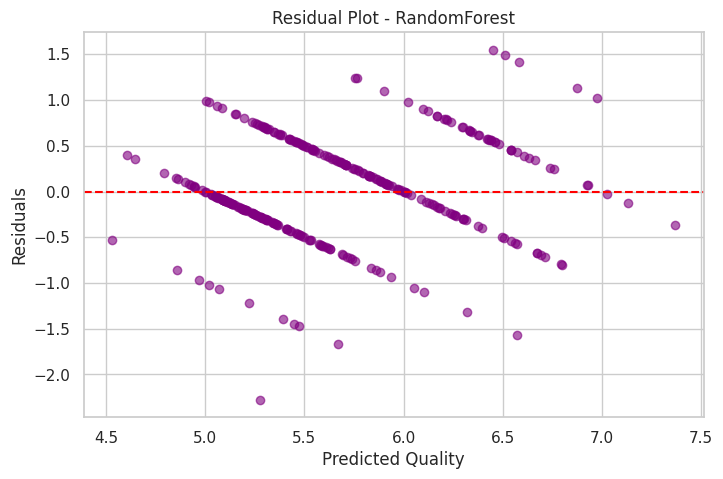

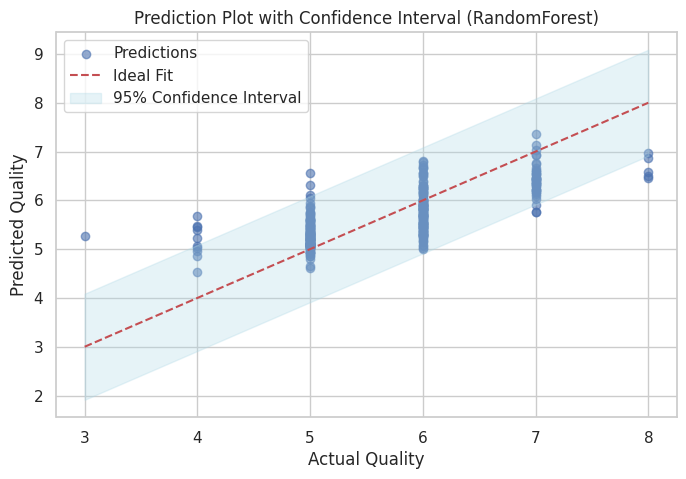

In [31]:
# ## Step 5.1: Model Evaluation Visualization (Regression)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

# Compare models
results = []
for name, mdl_info in regression_results.items(): # Use regression_results
    results.append(evaluate_model(name, mdl_info['model'], X_test_reg, y_test_reg)) # Use X_test_reg and y_test_reg

import pandas as pd
eval_df = pd.DataFrame(results).sort_values('R2', ascending=False)
display(eval_df)

# Best model visualization (assuming best model is the one with highest R2)
best_name = eval_df.iloc[0]['Model']
best_model = regression_results[best_name]['model'] # Access model from regression_results
y_pred_best = best_model.predict(X_test_reg) # Use X_test_reg

# Residual Plot
residuals = y_test_reg - y_pred_best # Use y_test_reg
plt.figure(figsize=(8,5))
plt.scatter(y_pred_best, residuals, alpha=0.6, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.title(f"Residual Plot - {best_name}")
plt.xlabel("Predicted Quality")
plt.ylabel("Residuals")
plt.show()

# Prediction Plot with Confidence Interval (95%)
y_pred_best = y_pred_best.flatten() if len(y_pred_best.shape) > 1 else y_pred_best
sigma = np.std(residuals)
ci = 1.96 * sigma

plt.figure(figsize=(8,5))
plt.scatter(y_test_reg, y_pred_best, alpha=0.6, label="Predictions") # Use y_test_reg
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', label="Ideal Fit") # Use y_test_reg
plt.fill_between(
    np.linspace(y_test_reg.min(), y_test_reg.max(), 100), # Use y_test_reg
    np.linspace(y_test_reg.min(), y_test_reg.max(), 100) - ci,
    np.linspace(y_test_reg.min(), y_test_reg.max(), 100) + ci,
    color="lightblue",
    alpha=0.3,
    label="95% Confidence Interval"
)
plt.title(f"Prediction Plot with Confidence Interval ({best_name})")
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.legend()
plt.show()

In [32]:
# Step 6: Deployment (save best models)
joblib.dump(best_reg, '/content/best_regression_model.joblib')
print('Saved models to /content/')

Saved models to /content/


## Step 7: Summary & Next Steps

- We performed EDA, built regression and classification models, tuned a few hyperparameters, and evaluated performance.
- **Observations:** alcohol and volatile acidity often correlate with quality; tree-based models generally perform better than linear models on this dataset.

**Next steps / improvements:**
- Expand hyperparameter search ranges and budgets (use randomized search or Bayesian optimization).
- Use feature engineering (interaction terms), and robust sampling for class imbalance (SMOTE).
- Try ensemble stacking and calibrated classifiers.

---

Notebook created and saved as `Red_Wine_Quality_CRISPDM.ipynb`.